# Importamos las librerias Pandas


In [2]:
import pandas as pd

##1. Preparación de Datos

## Importamos la base de datos titanic.csv y verificar si se cargo correctamente

In [3]:
df = pd.read_csv('titanic.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Hacemos la limpieza de datos de los valores numericos eliminando nulos


In [ ]:
# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include=['number'])

# Eliminar filas con valores nulos en las columnas numéricas seleccionadas
df_numeric_cleaned = df_numeric.dropna()

print("Base de Datos original:", df.shape)
print("Base de Datos filtrada con solo con numéricos:", df_numeric.shape)
print("Base de Datos con datos numericos numérico y limpio de nulos:", df_numeric_cleaned.shape)

display(df_numeric_cleaned.head())

# verificar los tipos de datos y valores no nulos
df_numeric_cleaned.info()

Base de Datos original: (891, 12)
Base de Datos filtrada con solo con numéricos: (891, 7)
Base de Datos con datos numericos numérico y limpio de nulos: (714, 7)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        714 non-null    int64  
 5   Parch        714 non-null    int64  
 6   Fare         714 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 44.6 KB


In [ ]:
#Confirmar que no hay ningún valor nulo en el nuevo dataframe
hay_nulo = df_numeric_cleaned.isnull().any().any()
print(hay_nulo)

False


In [ ]:
#queremos primero definir la variable objetivo del modelo. En este caso: "Survived"
X = df_numeric_cleaned[['Pclass', 'Age','SibSp','Parch','Fare']] # No se tendra en cuenta la variable PassengerID
y = df_numeric_cleaned['Survived']

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 1.0 MB/s eta 0:00:01    |████████████████                | 5.6 MB 7.1 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 8.0 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 651 kB/s eta 0:00:011
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
#Separar el dataframe entre train y test (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##2. Intuición Visual: El Hiperplano y el Margen

In [ ]:
df_2d = df_numeric_cleaned[['Age', 'Fare', 'Survived']]
display(df_2d.head())

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [ ]:
# Separar las variables predictoras y la variable objetivo
X_2d = df_2d[['Age', 'Fare']]
y_2d = df_2d['Survived']

# Dividir los datos 2D en conjuntos de entrenamiento y prueba (80/20)
from sklearn.model_selection import train_test_split
X_2d_train, X_2d_test, Y_2d_train, Y_2d_test = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import SVC

# Entrenar un modelo SVC con kernel='linear'
model_svc_2d_linear = SVC(kernel='linear', random_state=42)
model_svc_2d_linear.fit(X_2d_train, Y_2d_train)

# Hacer predicciones en el conjunto de prueba 2D
y_2d_pred_linear = model_svc_2d_linear.predict(X_2d_test)



In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn matplotlib numpy pandas gradio


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 14.6 MB/s eta 0:00:01
     |████████████████████████████████| 18.1 MB 1.0 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 5.4 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 3.9 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 8.8 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 730 kB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 4.2 MB/s eta 0:00:01
     |████████████████████████████████| 68 kB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 553 kB 10.9 MB/s eta 0:00:01
     |████████████████████████████████| 103 kB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 56 kB 7.3 MB/s eta 0:00:01
     |████████████████████████████████| 463 kB 11.1 MB/s eta 0:00:01
     |████████████████████████████████| 245 kB 6.6 MB/s eta 0:00:01
     |███████████████████████████████

Matplotlib is building the font cache; this may take a moment.
/Users/juandavidnietodallos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


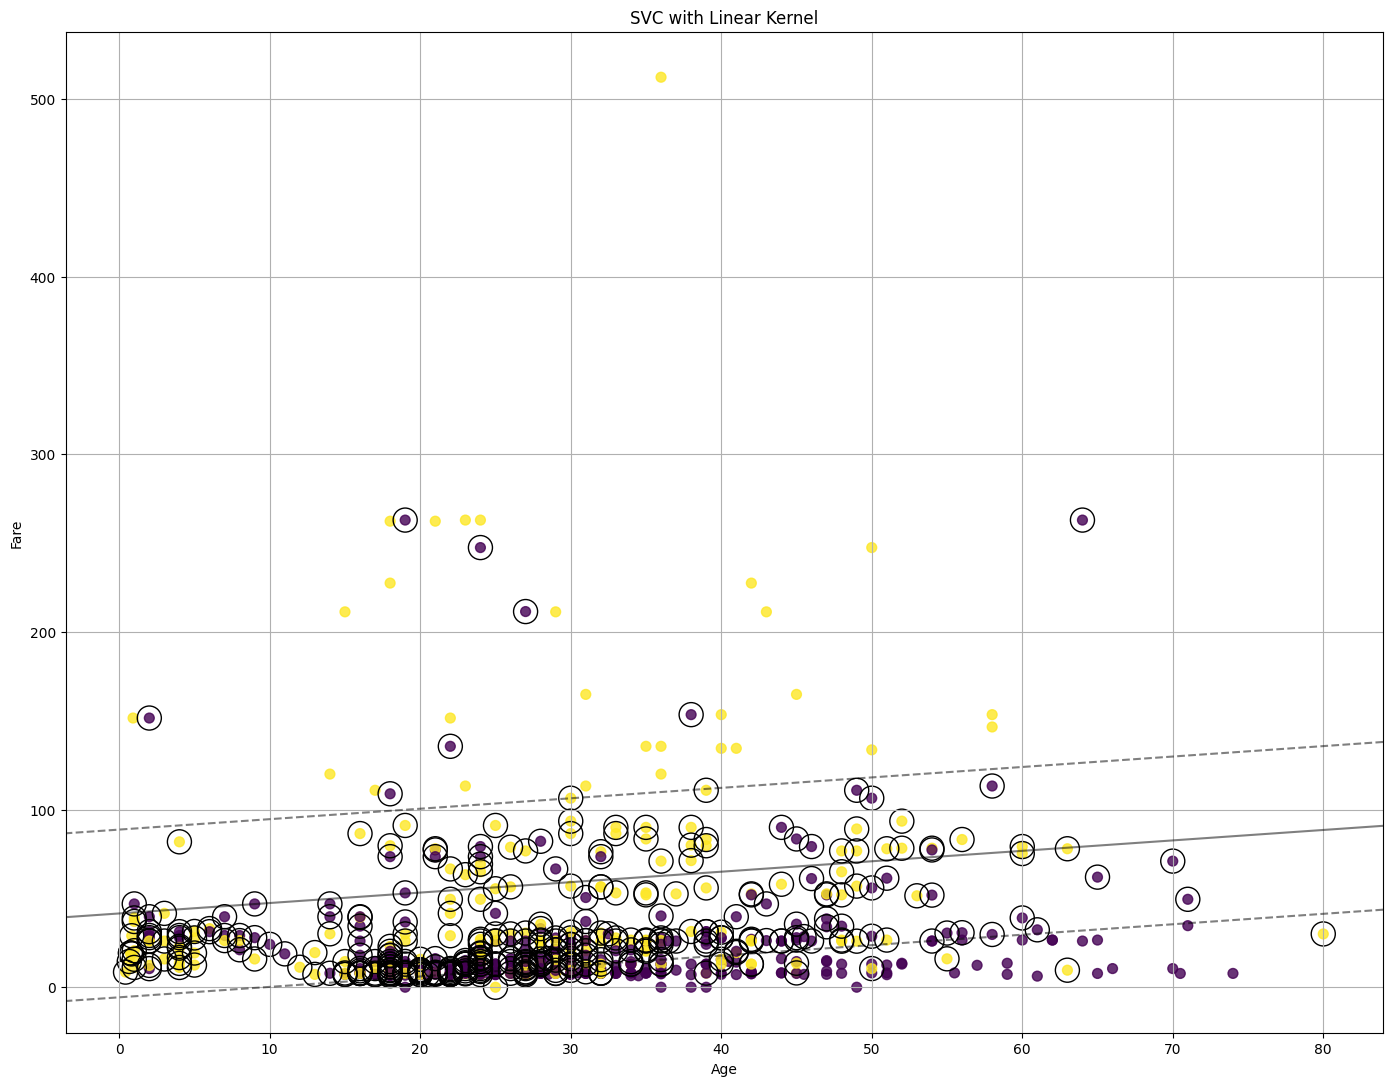

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='black')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Create the scatter plot
plt.figure(figsize=(17, 13))
plt.scatter(X_2d_train['Age'], X_2d_train['Fare'], c=Y_2d_train, s=50, cmap='viridis', alpha=0.8)

# Plot the decision boundary and margins from the trained linear SVC model
plot_svc_decision_function(model_svc_2d_linear)

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('SVC with Linear Kernel')
plt.grid(True)
plt.show()


 
##  3. El Impacto de la Regularización $C$

In [ ]:
# Separar las variables predictoras y la variable objetivo
X_d = df_numeric_cleaned[['Pclass', 'Age','SibSp','Parch','Fare']]
y_d = df_numeric_cleaned['Survived']

# Dividir los datos 2D en conjuntos de entrenamiento y prueba (80/20)
from sklearn.model_selection import train_test_split
X_2d_train, X_2d_test, Y_2d_train, Y_2d_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import SVC

# Entrenar modelo SVC A con kernel='linear' y C = 0.001
modeloSVCA = SVC(kernel='linear', C = 0.001, random_state=42)
modeloSVCA.fit(X_2d_train, Y_2d_train)

# Hacer predicciones en el conjunto de prueba 2D
y_pred1 = modeloSVCA.predict(X_2d_test)

In [ ]:
from sklearn.svm import SVC

# Entrenar modelo SVC B con kernel='linear' y C = 1000
modeloSVCB = SVC(kernel='linear', C = 1000, random_state=42)
modeloSVCB.fit(X_2d_train, Y_2d_train)

# Hacer predicciones en el conjunto de prueba 2D
y_pred2 = modeloSVCB.predict(X_2d_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
#Matriz de Confusion para MODELO A con datos de Entrenamiento
y_pred1_train = modeloSVCA.predict(X_2d_train)

conf_matrix = confusion_matrix(Y_2d_train, y_pred1_train)
print(f"Confusion Matrix:\n{conf_matrix}")

accuracy_train_A = accuracy_score(Y_2d_train, y_pred1_train)
print(f"Accuracy (train): {accuracy_train_A:.4f}")

Confusion Matrix:
[[313  24]
 [170  64]]
Accuracy (train): 0.6602


In [ ]:
#Matriz de Confusion para MODELO A con datos de Prueba

conf_matrix = confusion_matrix(Y_2d_test, y_pred1)
print(f"Confusion Matrix:\n{conf_matrix}")

accuracy_test_A = accuracy_score(Y_2d_test, y_pred1)
print(f"Accuracy (test): {accuracy_test_A:.4f}")

Confusion Matrix:
[[83  4]
 [45 11]]
Accuracy (test): 0.6573


In [ ]:
#Matriz de Confusion para MODELO B con datos de Entrenamiento
y_pred2_train = modeloSVCB.predict(X_2d_train)

conf_matrix = confusion_matrix(Y_2d_train, y_pred2_train)
print(f"Confusion Matrix:\n{conf_matrix}")

accuracy_train_B = accuracy_score(Y_2d_train, y_pred2_train)
print(f"Accuracy (train): {accuracy_train_B:.4f}")

Confusion Matrix:
[[286  51]
 [107 127]]
Accuracy (train): 0.7233


In [ ]:
#Matriz de Confusion para MODELO B con datos de Prueba

conf_matrix = confusion_matrix(Y_2d_test, y_pred2)
print(f"Confusion Matrix:\n{conf_matrix}")

accuracy_test_B = accuracy_score(Y_2d_test, y_pred2)
print(f"Accuracy (test): {accuracy_test_B:.4f}")

Confusion Matrix:
[[75 12]
 [31 25]]
Accuracy (test): 0.6993


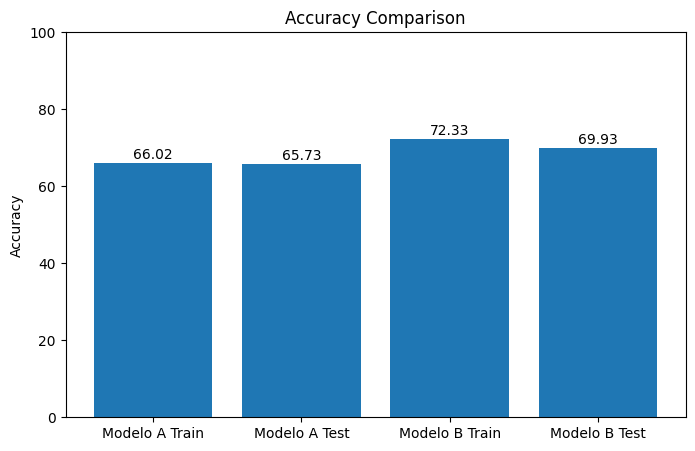

In [ ]:
#Visualización de valores de accuracy
import matplotlib.pyplot as plt


accuracies = [
    accuracy_train_A*100,
    accuracy_test_A*100,
    accuracy_train_B*100,
    accuracy_test_B*100
]

labels = [
    'Modelo A Train',
    'Modelo A Test',
    'Modelo B Train',
    'Modelo B Test'
]

plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies)

plt.ylim(0, 100)
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')

for i in range(len(accuracies)):
  accuracies[i]=round(accuracies[i],2)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f'{value}', ha='center')

plt.show()

# Explicacion sobre de cual modelo es el mejor:

De acuerdo a los resultados que salieron en los modelos, el modelo con C=1000 es el mejor candidato porque obtiene mayor accuracy tanto en el entrenamiento como en la prueba. Lo mas es que rinde mejor en el test, que es lo que nos importa para generalizar; la diferencia entre el entrenamiento y el test es un poco mayor, lo cual sugiere que el modelo C=1000 tiene mas ajuste al entranamiento por tener un C mas alto lo cual causa menos regularizacion. No parece un sobre ajuste fuerte porque el desempeño de la prueba tambien sube. Además, el cambio de porcentaje entre ambos modelos con ambos grupos de datos es mínimo, lo cual indica que ambos esta rindiendo de manera adecuada y sin complicaciones.

##4. El "Truco del Kernel" y Optimización

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [ ]:
parameters = [
    {'kernel': ['linear'], 'C': [0.01, 1, 100]},

    {'kernel': ['rbf'], 'C': [0.01, 1, 100], 'gamma': ['scale', 'auto']},

    {'kernel': ['poly'], 'C': [0.01, 1, 100], 'gamma': ['scale']}
]

grid2 = GridSearchCV(SVC(probability = True), parameters, cv=3, n_jobs=-1)
grid2.fit(X_2d_train, Y_2d_train)
print(grid2)
print(f"Mejor puntaje Accuracy:\n{grid2.best_score_}")

GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid=[{'C': [0.01, 1, 100], 'kernel': ['linear']},
                         {'C': [0.01, 1, 100], 'gamma': ['scale', 'auto'],
                          'kernel': ['rbf']},
                         {'C': [0.01, 1, 100], 'gamma': ['scale'],
                          'kernel': ['poly']}])
Mejor puntaje Accuracy:
0.724993111049876


In [ ]:
print(f"Mejores Parametros:\n{grid2.best_params_}")

Mejores Parametros:
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


### ¿El mejor modelo fue lineal o no lineal? ¿Qué nos dice esto sobre la estructura de los datos de supervivencia?

Según los resultados del GridSearchCV, el mejor modelo tuvo aquello combinación de parametros de la siguiente manera: Un kernel de tipo **RBF**, un valor C de **100** y una Gamma de tipo **Scale**. Esta combinación obtuv+o un puntaje de accuracy de **72.5%** lo cual se considera como un valor moderado y por encíma del promedio.

En fín, el mejor modelo fue no lineal. Esto nos da la idea de que la estructura de los datos de superivviencia no se pueden separarse linealmente. Por ende, se requiere un límite de decisión curvo para separar a los sobrevivientes de los no sobrevivientes.

##5. Comparación y Despliegue

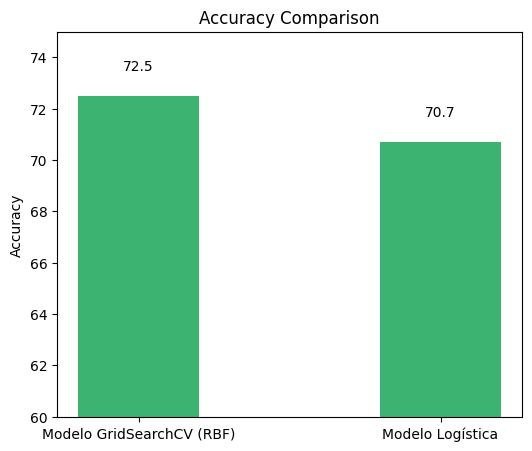

In [ ]:
#Visualización de valores de accuracy entre modelos
import matplotlib.pyplot as plt


accuracies = [
    grid2.best_score_*100,
    0.7070*100,
]

labels = [
    'Modelo GridSearchCV (RBF)',
    'Modelo Logística'
]

plt.figure(figsize=(6, 5))
plt.bar(labels, accuracies, width = 0.4, align = 'center', color = 'mediumseagreen')

plt.ylim(60, 75)
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')

for i in range(len(accuracies)):
  accuracies[i]=round(accuracies[i],2)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f'{value}', ha='center')

plt.show()

In [ ]:
tabla_acc = pd.DataFrame({
    "Model": [
        "SVM (RBF, GridSearchCV)",
        "Logística"
    ],
    "Accuracy": [
        grid2.best_score_*100,
        0.7070*100
    ]
})

# Optional formatting
tabla_acc["Accuracy"] = tabla_acc["Accuracy"].round(2)

def highlight_best(row):
    if row["Accuracy"] == tabla_acc["Accuracy"].max():
        return ["background-color: green", "background-color: green"]
    return ["", ""]

# Apply styling
tabla_fin = (
    tabla_acc.style
    .apply(highlight_best, axis=1)
    .set_properties(**{
        "border": "1px solid black",
        "text-align": "center"
    })
    .set_table_styles([
        {"selector": "th", "props": [("border", "1px solid black"),
                                     ("text-align", "center")]}
    ])
)

tabla_fin = tabla_fin.format({"Accuracy": "{:.2f}"})
tabla_fin

,Model,Accuracy
0,"SVM (RBF, GridSearchCV)",72.50
1,Logística,70.70


Comparando los valores de accuracy del modelo RBF y del modelo Logística. Se puede ver que hay una diferencia menudo pero el modelo RBF gana con un puntaje de **72.5%** a comparación de la logísitca que tiene un puntaje de **70.7%**

##Interfaz Gráfica Gradio

In [ ]:
pip install gradio

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
!{sys.executable} -m pip install --upgrade huggingface_hub


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
import sys
!{sys.executable} -m pip install "gradio==4.44.1" --force-reinstall


Defaulting to user installation because normal site-packages is not writeable
  Using cached gradio-4.44.1-py3-none-any.whl (18.1 MB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl (32 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
  Using cached anyio-4.12.1-py3-none-any.whl (113 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl (15 kB)
  Using cached MarkupSafe-2.1.5-cp39-cp39-macosx_10_9_universal2.whl (18 kB)
  Using cached typer-0.23.2-py3-none-any.whl (56 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
  Using cached fastapi-0.128.8-py3-none-any.whl (103 kB)
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
  Using cached uvicorn-0.39.0-py3-none-any.whl (68 kB)
     |████████████████████████████████| 74 kB 1.4 MB/s eta 0:00:01
  Using cached pillow-10.4.0-cp39-cp39-macosx_11_0_arm64.whl (3.4

In [ ]:
import gradio as gr
import numpy as np

def predict_survival(pclass, age, sibsp, parch, fare):
    features = np.array([[pclass, age, sibsp, parch, fare]])
    probability = grid2.predict_proba(features)[0][1]
    return f"Probabilidad de Supervivencia: {probability:.2f}"

/Users/juandavidnietodallos/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (/Users/juandavidnietodallos/Library/Python/3.9/lib/python/site-packages/huggingface_hub/__init__.py)

In [ ]:
iface = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Number(label='Pclass (1, 2, or 3)', minimum=1, maximum=3, step=1),
        gr.Number(label='Age', minimum=0, maximum=80),
        gr.Number(label='SibSp (Number of Siblings/Spouses Aboard)', minimum=0, maximum=8),
        gr.Number(label='Parch (Number of Parents/Children Aboard)', minimum=0, maximum=6),
        gr.Number(label='Fare', minimum=0, maximum=512.3292)
    ],
    outputs='text',
    title='Titanic Survival Predictor',
    description='Enter passenger details to predict the probability of survival.'
)

iface.launch(share=True)

NameError: name 'gr' is not defined